In [5]:
from pathlib import Path

# Code_Picture.ipynb 与 data 文件夹位于同一项目目录
PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "data"

if not DATA_DIR.exists():
    raise FileNotFoundError(f"找不到数据目录: {DATA_DIR}")

print(f"数据目录: {DATA_DIR}")

数据目录: /workspaces/Theta-Phase-Synchronization-Links-Endogenous-Frontal-Theta-Fluctuations-and-Conscious-Visual-Access/data


findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


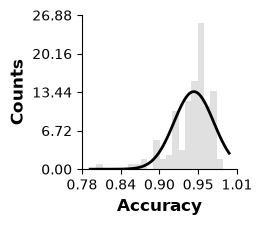

In [2]:
## Figure 1B
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns
import pandas as pd
from matplotlib.ticker import MaxNLocator,FuncFormatter

# Download the dataset
df = pd.read_excel(DATA_DIR / 'trial sort_trial.xlsx')

# Select one column to plot
#median_reaction_time = df.groupby('subj_index')['rt'].median()
subject_counts = df['subj_index'].value_counts()/160

# Calculate the histogram
#counts, bins = np.histogram(median_reaction_time, bins=20, density=True)
counts, bins = np.histogram(subject_counts, bins=20, density=True)
# Calculate the parameters for the normal distribution
#mu, std = norm.fit(median_reaction_time)
mu, std = norm.fit(subject_counts)

# Create the plot
fig, ax = plt.subplots(figsize=(2, 2))
#ax.bar(bins[:-1], counts, width=np.diff(bins), alpha=0.7, color='k')
ax.bar(bins[:-1], counts, width=np.diff(bins), alpha=0.7, color='lightgray')

# Remove the right and top axes
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Plot the PDF
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
#ax.plot(x, p, 'lightgray', linewidth=2)
ax.plot(x, p, 'k', linewidth=2)

#ax.set_xlabel('Reaction time (s)', fontsize=12, fontname="Times New Roman",weight='bold')
ax.set_xlabel('Accuracy', fontsize=12, fontname="Times New Roman",weight='bold')
ax.set_ylabel('Counts', fontsize=12, fontname="Times New Roman",weight='bold')

# Set the number of y-ticks
ax.set_yticks(np.linspace(ax.get_ylim()[0], ax.get_ylim()[1], 5))
#ax.set_xlim(0.48, 2.68)
#ax.set_xticks(np.linspace(0.48, 2.68, 5))
ax.set_xlim(0.78, 1.01)
ax.set_xticks(np.linspace(0.78, 1.01, 5))

# Format y-axis and x-axis to one decimal place
formatter = FuncFormatter(lambda x, pos: '{:.2f}'.format(x))
ax.xaxis.set_major_formatter(formatter)
ax.yaxis.set_major_formatter(formatter)

plt.show()

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


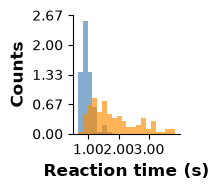

In [3]:
## Figure 1C
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import FuncFormatter

# Load trial-level RT data
df = pd.read_excel(DATA_DIR / 'trial sort_trial.xlsx')

# Calculate each subject's median RT separately for the fast and slow groups
subject_medians = (
    df.groupby(['subj_index', 'rt_group2'])['rt']
      .median()
      .reset_index()
)
rt_fast = subject_medians.loc[subject_medians['rt_group2'] == 1, 'rt'].dropna().to_numpy()
rt_slow = subject_medians.loc[subject_medians['rt_group2'] == 2, 'rt'].dropna().to_numpy()

if rt_fast.size == 0 or rt_slow.size == 0:
    raise ValueError('rt_group2 must contain observations for both groups 1 and 2')

# Use common bins so the two subject-level distributions are comparable
all_rt = np.concatenate([rt_fast, rt_slow])
bins = np.histogram_bin_edges(all_rt, bins=20)
fig, ax = plt.subplots(figsize=(2, 2))

ax.hist(rt_fast, bins=bins, density=True, alpha=0.65, color='steelblue')
ax.hist(rt_slow, bins=bins, density=True, alpha=0.65, color='darkorange')

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_xlabel('Reaction time (s)', fontsize=12, fontname='Times New Roman', weight='bold')
ax.set_ylabel('Counts', fontsize=12, fontname='Times New Roman', weight='bold')
ax.set_xticks([1, 2, 3])
ax.set_yticks(np.linspace(ax.get_ylim()[0], ax.get_ylim()[1], 5))
ax.xaxis.set_major_formatter(FuncFormatter(lambda value, position: f'{value:.2f}'))
ax.yaxis.set_major_formatter(FuncFormatter(lambda value, position: f'{value:.2f}'))

plt.tight_layout()
plt.show()

Text(0, 0.5, 'ISPC (%)')

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


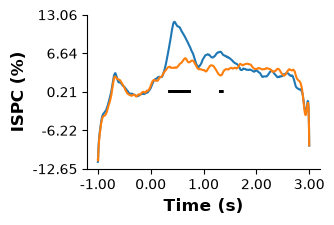

In [7]:
## Figure 3A，left
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
import seaborn as sns
import pandas as pd
from matplotlib.ticker import MaxNLocator,FuncFormatter
from scipy.stats import ttest_rel
from statsmodels.stats.multitest import multipletests
# Download the dataset
data = loadmat(DATA_DIR / 'wholedata_subtractbase.mat')['wholedata_subtractbase']

# Create the figure with 3 subplots
fig, ax = plt.subplots(figsize=(3, 2))
data1 = data[:,0, :]  # replace with your group indices
data2 = data[:,1, :]

p_values = []

# Perform a paired t-test for each time point
for i in range(data1.shape[1]):
    _, p_value = ttest_rel(data1[:, i], data2[:, i])
    p_values.append(p_value)
    
# Convert the list of p-values to a numpy array
p_values = np.array(p_values)
p_values = np.nan_to_num(p_values, nan=1)

# FDR correction using the Benjamini-Hochberg procedure
_, p_values_fdr, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')

mean1 = np.mean(data1, axis=0)
sem1 = np.std(data1, axis=0) / np.sqrt(111)

mean2 = np.mean(data2, axis=0)
sem2 = np.std(data2, axis=0) / np.sqrt(111)


time = np.linspace(-1, 3, mean1.shape[0])
    # Remove the right and top axes
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.plot(time, mean1, label='Slow')
ax.plot(time, mean2, label='Fast')

significant_time_points = time[p_values_fdr < 0.05]
for t in significant_time_points:
    ax.hlines(y=0.37, xmin=t-0.01, xmax=t+0.01, color='black', linewidth=2)  # 在显著时间点绘制短黑线


    # Set the number of y-ticks
ax.set_yticks(np.linspace(ax.get_ylim()[0], ax.get_ylim()[1], 5))
ax.set_xticks([-1,0,1,2,3])

# Format y-axis and x-axis to one decimal place
formatter = FuncFormatter(lambda x, pos: '{:.2f}'.format(x))
ax.xaxis.set_major_formatter(formatter)
ax.yaxis.set_major_formatter(formatter)

plt.xlabel('Time (s)', fontsize=12, fontname="Times New Roman",weight='bold')
plt.ylabel('ISPC (%)', fontsize=12, fontname="Times New Roman",weight='bold')

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


r1显著时间段: 0.31-0.54 s
r2显著时间段: 0.45-1.28 s


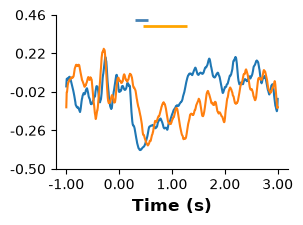

In [9]:
## Figure 3A，right
import matplotlib.pyplot as plt
import numpy as np
import scipy.io as sio
import pandas as pd
import scipy.stats as stats
from matplotlib.ticker import MaxNLocator,FuncFormatter
from statsmodels.stats.multitest import multipletests

# Load the data
data1 = sio.loadmat(DATA_DIR / 'istp_fast.mat')['istpfast']
data2 = sio.loadmat(DATA_DIR / 'istp_slow.mat')['istpslow']
data1_del = np.delete(data1, 70, axis=0)
data2_del = np.delete(data2, 70, axis=0)
df = pd.read_excel(DATA_DIR / 'theta_alpha_erp_median.xlsx')
rt_data = df['rt'].values
rt1 = rt_data[0:110]
rt2 = rt_data[110:220]
#rt2 = rt_data[0:110]

r1 = np.zeros(1000)
p1 = np.zeros(1000)
r2 = np.zeros(1000)
p2 = np.zeros(1000)
for i in range(1000):
    r1[i],p1[i] = stats.pearsonr(rt1, data1_del[:,i],alternative='two-sided')
    r2[i],p2[i] = stats.pearsonr(rt2, data2_del[:,i],alternative='two-sided')

_, p1_corrected, _, _ = multipletests(p1, alpha=0.05, method='fdr_bh')
_, p2_corrected, _, _ = multipletests(p2, alpha=0.05, method='fdr_bh')
time = np.linspace(-1, 3, len(r1))  

fig, ax = plt.subplots(figsize=(3, 2))
# 绘制相关系数曲线
plt.plot(time, r1)
plt.plot(time, r2)
ax.set_ylim(-0.5, 0.46)
# 绘制显著部分的横线
significant_time_r1 = time[p1_corrected <= 0.05]
significant_time_r2 = time[p2_corrected <= 0.05]

if len(significant_time_r1) > 0:
    print(f'r1显著时间段: {significant_time_r1[0]:.2f}-{significant_time_r1[-1]:.2f} s')
    ax.hlines(y=0.43, xmin=significant_time_r1[0], xmax=significant_time_r1[-1], color='steelblue', linewidth=2)

if len(significant_time_r2) > 0:
    print(f'r2显著时间段: {significant_time_r2[0]:.2f}-{significant_time_r2[-1]:.2f} s')
    ax.hlines(y=0.39, xmin=significant_time_r2[0], xmax=significant_time_r2[-1], color='orange', linewidth=2)

# Remove the right and top axes
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.xlabel('Time (s)', fontsize=12, fontname="Times New Roman",weight='bold')
#plt.ylabel('Pearson correlation', fontsize=12, fontname="Times New Roman",weight='bold')
#plt.title('ERP with Error Band', fontsize=12, fontname="Times New Roman")
#plt.legend(loc='upper right',ncol=1)

# Set the number of y-ticks
ax.set_yticks(np.linspace(ax.get_ylim()[0], ax.get_ylim()[1], 5))

# Format y-axis and x-axis to one decimal place
formatter = FuncFormatter(lambda x, pos: '{:.2f}'.format(x))
ax.xaxis.set_major_formatter(formatter)
ax.yaxis.set_major_formatter(formatter)

plt.show()

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


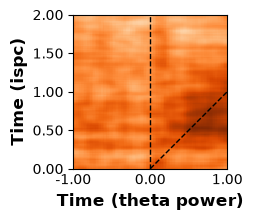

In [10]:
## Figure 3B, left and middle
## correlation between theta power and ispc, fast: corr_poweristp_r_rest(fast).npy; slow:corr_poweristp_r_rest(fslow).npy
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.multitest import multipletests

# load data (use data directory in this workspace)
z_all = np.load(DATA_DIR / 'corr_poweristp_r_rest(slow).npy') 
z = z_all[:,:]
fig, ax = plt.subplots(figsize=(2, 2))
# ensure image is drawn below axis lines
im = ax.imshow(z[251:750,0:100], aspect=1, interpolation='nearest', cmap='Oranges',
               origin='lower', extent=[-1,1,0,2], vmin=-0.5, vmax=0.5, zorder=1)  # Blues-fast; Oranges-slow
ax.set_xlabel('Time (theta power)', fontsize=12, fontname="Times New Roman", weight='bold')
ax.set_ylabel('Time (ispc)', fontsize=12, fontname="Times New Roman", weight='bold')

# vertical dashed line at x=0 (full y-range shown)
ax.vlines(x=0, ymin=0, ymax=2, color='black', linestyle='--', linewidth=1, zorder=5)
# dashed diagonal from (0,0) to (1,1)
ax.plot([0, 1], [0, 1], color='black', linestyle='--', linewidth=1, zorder=5)

# axis formatting
formatter = FuncFormatter(lambda x, pos: '{:.2f}'.format(x))
ax.xaxis.set_major_formatter(formatter)
ax.yaxis.set_major_formatter(formatter)
plt.tick_params(axis='x', length=0)

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


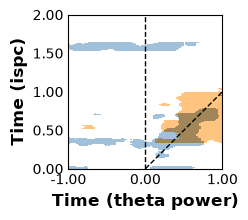

In [13]:
## Figure 3B, right
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.ticker import MaxNLocator,FuncFormatter
z1 = np.load(DATA_DIR / 'corr_poweristp_filtered_r_rest(fast).npy')
z2 = np.load(DATA_DIR / 'corr_poweristp_filtered_r_rest(slow).npy')  # 假设这是另一组数据

# color mapping for the two datasets
colors1 = ['w', 'steelblue']  
cmap_custom1 = ListedColormap(colors1)
colors2 = ['w', 'darkorange']  
cmap_custom2 = ListedColormap(colors2)

fig, ax = plt.subplots(figsize=(2, 2))

im1 = ax.imshow(z1[251:750,0:100], aspect=1, interpolation='nearest', cmap=cmap_custom1,
                origin='lower', extent=[-1, 1, 0, 2], vmin=0, vmax=1, alpha=1)

im2 = ax.imshow(z2[251:750,0:100], aspect=1, interpolation='nearest', cmap=cmap_custom2,
                origin='lower', extent=[-1, 1, 0, 2], vmin=0, vmax=1, alpha=0.5)  # 使用alpha参数调整透明度

# adding vertical dashed line at x=0 and dashed diagonal from (0,0) to (1,1)
ax.vlines(x=0, ymin=0, ymax=2, color='black', linestyle='--', linewidth=1, zorder=5)
ax.plot([0, 1], [0, 1], color='black', linestyle='--', linewidth=1, zorder=5)

ax.set_xlabel('Time (theta power)', fontsize=12, fontname="Times New Roman", weight='bold')
ax.set_ylabel('Time (ispc)', fontsize=12, fontname="Times New Roman", weight='bold')
ax.set_yticks(np.linspace(ax.get_ylim()[0], ax.get_ylim()[1], 5))

# Format y-axis and x-axis to one decimal place
formatter = FuncFormatter(lambda x, pos: '{:.2f}'.format(x))
ax.xaxis.set_major_formatter(formatter)
ax.yaxis.set_major_formatter(formatter)
plt.tick_params(axis='x', length=0)
plt.tick_params(axis='y', length=0)

plt.show()

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


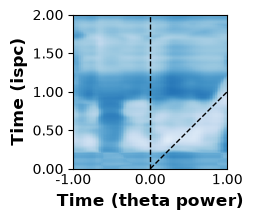

In [15]:
## Figure 3C, top/bottom left and middle
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.multitest import multipletests

# load data (use data directory in this workspace)
z_all = np.load(DATA_DIR / 'mediation_z_rest(fast).npy') 
z = z_all[:,:]
fig, ax = plt.subplots(figsize=(2, 2))
# ensure image is drawn below axis lines
im = ax.imshow(z[251:750,0:100], aspect=1, interpolation='nearest', cmap='Blues',
               origin='lower', extent=[-1,1,0,2], vmin=-4, vmax=4, zorder=1)  # Blues-fast; Oranges-slow
ax.set_xlabel('Time (theta power)', fontsize=12, fontname="Times New Roman", weight='bold')
ax.set_ylabel('Time (ispc)', fontsize=12, fontname="Times New Roman", weight='bold')

# vertical dashed line at x=0 (full y-range shown)
ax.vlines(x=0, ymin=0, ymax=2, color='black', linestyle='--', linewidth=1, zorder=5)
# dashed diagonal from (0,0) to (1,1)
ax.plot([0, 1], [0, 1], color='black', linestyle='--', linewidth=1, zorder=5)

# axis formatting
formatter = FuncFormatter(lambda x, pos: '{:.2f}'.format(x))
ax.xaxis.set_major_formatter(formatter)
ax.yaxis.set_major_formatter(formatter)
plt.tick_params(axis='x', length=0)

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


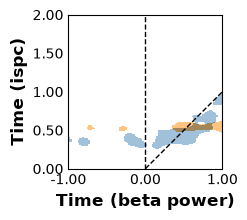

In [17]:
## Figure 3C, top/bottom right
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.ticker import MaxNLocator,FuncFormatter
z1 = np.load(DATA_DIR / 'mediation_filtered_z_rest(fast).npy')
z2 = np.load(DATA_DIR / 'mediation_filtered_z_rest(slow).npy')  # 假设这是另一组数据

colors1 = ['w', 'steelblue']  
cmap_custom1 = ListedColormap(colors1)
colors2 = ['w', 'darkorange'] 
cmap_custom2 = ListedColormap(colors2)

fig, ax = plt.subplots(figsize=(2, 2))

im1 = ax.imshow(z1[251:750,0:100], aspect=1, interpolation='nearest', cmap=cmap_custom1,
                origin='lower', extent=[-1, 1, 0, 2], vmin=0, vmax=1, alpha=1)

im2 = ax.imshow(z2[251:750,0:100], aspect=1, interpolation='nearest', cmap=cmap_custom2,
                origin='lower', extent=[-1, 1, 0, 2], vmin=0, vmax=1, alpha=0.5)  # 使用alpha参数调整透明度

# 添加参考线：x=0 的纵虚线，以及从 (0,0) 到 (1,1) 的虚线
ax.vlines(x=0, ymin=0, ymax=2, color='black', linestyle='--', linewidth=1, zorder=5)
ax.plot([0, 1], [0, 1], color='black', linestyle='--', linewidth=1, zorder=5)

ax.set_xlabel('Time (beta power)', fontsize=12, fontname="Times New Roman", weight='bold')
ax.set_ylabel('Time (ispc)', fontsize=12, fontname="Times New Roman", weight='bold')
ax.set_yticks(np.linspace(ax.get_ylim()[0], ax.get_ylim()[1], 5))

# Format y-axis and x-axis to one decimal place
formatter = FuncFormatter(lambda x, pos: '{:.2f}'.format(x))
ax.xaxis.set_major_formatter(formatter)
ax.yaxis.set_major_formatter(formatter)
plt.tick_params(axis='x', length=0)
plt.tick_params(axis='y', length=0)

plt.show()

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


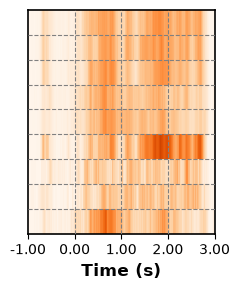

In [18]:
## Figure 4A, left and right
## fast-blue, propotion_channels_ispc(fast).npy; slow-orange, propotion_channels_ispc(slow).npy
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# load proportion matrix: rows = 9 parts, columns = time points
prop = np.load(DATA_DIR / 'propotion_channels_ispc(slow).npy')
prop = np.asarray(prop)

if prop.ndim != 2:
    raise ValueError(f'Expected 2D array, got shape {prop.shape}')

if prop.shape[0] != 9:
    if prop.shape[1] == 9:
        prop = prop.T
    else:
        raise ValueError(f'Unexpected shape for proportion matrix: {prop.shape}')

# scale to 0-100%
prop = prop * 100

# plot
fig, ax = plt.subplots(figsize=(2.5, 3))

im = ax.imshow(
    prop,
    origin='lower',
    aspect='auto',
    cmap='Oranges', # fast-Blues, slow-Oranges
    interpolation='nearest',
    extent=[-1, 3, 0, 9],
    vmin=0,
    vmax=100,
    zorder=1,
)

# horizontal divider lines between parts
for i in range(1, 9):
    ax.hlines(i, -1, 3, colors='gray', linestyles='--', linewidth=0.8, zorder=3)

# vertical reference lines at x=0, 1, 2
for x0 in [0, 1, 2]:
    ax.vlines(x0, 0, 9, colors='gray', linestyles='--', linewidth=0.8, zorder=4)

# outer border
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(1.2)

ax.set_xlim(-1, 3)
ax.set_ylim(0, 9)
ax.set_xticks([-1, 0, 1, 2, 3])
ax.set_yticks([])
ax.set_xlabel('Time (s)', fontsize=12, fontname='Times New Roman', weight='bold')
ax.set_ylabel('')

# format x tick labels as 2 decimals for -1.00, 0.00 etc.
formatter = FuncFormatter(lambda v, pos: f'{v:.2f}')
ax.xaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


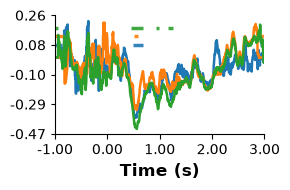

In [20]:
## Figure 4B, upper and lower
## fast, sigchannels_ispc_rt_r(fast), sigchannels_ispc_rt_p_corrected(fast).npy; 
## slow, sigchannels_ispc_rt_r(slow), sigchannels_ispc_rt_p_corrected(slow).npy; 
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

base = DATA_DIR
r = np.load(base / 'sigchannels_ispc_rt_r(slow).npy')
p = np.load(base / 'sigchannels_ispc_rt_p_corrected(slow).npy')

r = np.asarray(r)
p = np.asarray(p)

# make the array layout consistent with 9 parts x timepoints
if r.shape[0] != 9 and r.shape[1] == 9:
    r = r.T
if p.shape[0] != 9 and p.shape[1] == 9:
    p = p.T

if r.shape[0] < 9:
    raise ValueError(f'Expected at least 9 rows for parts, got {r.shape}')

time = np.linspace(-1, 3, r.shape[1])
parts = [0, 3, 6]
colors = {0: 'tab:blue', 3: 'tab:orange', 6: 'tab:green'}
significance_heights = {0: 0.08, 3: 0.13, 6: 0.18}
fig, ax = plt.subplots(figsize=(3, 2))

for part in parts:
    y = r[part]
    sig = p[part] <= 0.05
    ax.plot(time, y, color=colors[part], linewidth=1.8)

    baseline = significance_heights[part]
    if np.any(sig):
        start = None
        for idx, flag in enumerate(sig):
            if flag and start is None:
                start = idx
            elif (not flag) and start is not None:
                ax.hlines(baseline, time[start], time[idx - 1],
                          color=colors[part], linewidth=2.5, alpha=0.9)
                start = None
        if start is not None:
            ax.hlines(baseline, time[start], time[-1],
                      color=colors[part], linewidth=2.5, alpha=0.9)

ax.set_xlim(-1, 3)
ax.set_xticks([-1, 0, 1, 2, 3])
#ax.set_ylim(-0.37, 0.29)
ax.set_ylim(-0.47, 0.26)
#ax.set_yticks(np.linspace(-0.37, 0.29, 5))
ax.set_yticks(np.linspace(-0.47, 0.26, 5))
ax.xaxis.set_major_formatter(FuncFormatter(lambda value, position: f'{value:.2f}'))
ax.yaxis.set_major_formatter(FuncFormatter(lambda value, position: f'{value:.2f}'))
ax.set_xlabel('Time (s)', fontsize=12, fontname='Times New Roman', weight='bold')
ax.set_ylabel('')
ax.tick_params(axis='y', length=3, labelleft=True)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


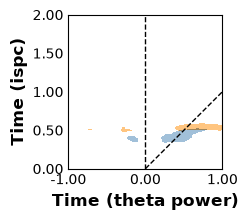

In [21]:
## Figure 4C, left, middle and right
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.ticker import MaxNLocator,FuncFormatter
z11 = np.load(DATA_DIR / 'mediation_chan_filtered_z_rest(fast).npy')
z21 = np.load(DATA_DIR / 'mediation_chan_filtered_z_rest(slow).npy')  # 假设这是另一组数据

z1 = z11[0,:,:] # 0:frontal; 3：posterior; 6:frontal-posterior
z2 = z21[0,:,:]
# color mapping for the two datasets
colors1 = ['w', 'steelblue']  
cmap_custom1 = ListedColormap(colors1)
colors2 = ['w', 'darkorange']  
cmap_custom2 = ListedColormap(colors2)

fig, ax = plt.subplots(figsize=(2, 2))

im1 = ax.imshow(z1[251:750,0:100], aspect=1, interpolation='nearest', cmap=cmap_custom1,
                origin='lower', extent=[-1, 1, 0, 2], vmin=0, vmax=1, alpha=1)

im2 = ax.imshow(z2[251:750,0:100], aspect=1, interpolation='nearest', cmap=cmap_custom2,
                origin='lower', extent=[-1, 1, 0, 2], vmin=0, vmax=1, alpha=0.5)  # 使用alpha参数调整透明度

# adding reference lines: vertical dashed line at x=0, and dashed diagonal from (0,0) to (1,1)
ax.vlines(x=0, ymin=0, ymax=2, color='black', linestyle='--', linewidth=1, zorder=5)
ax.plot([0, 1], [0, 1], color='black', linestyle='--', linewidth=1, zorder=5)

ax.set_xlabel('Time (theta power)', fontsize=12, fontname="Times New Roman", weight='bold')
ax.set_ylabel('Time (ispc)', fontsize=12, fontname="Times New Roman", weight='bold')
ax.set_yticks(np.linspace(ax.get_ylim()[0], ax.get_ylim()[1], 5))

# Format y-axis and x-axis to one decimal place
formatter = FuncFormatter(lambda x, pos: '{:.2f}'.format(x))
ax.xaxis.set_major_formatter(formatter)
ax.yaxis.set_major_formatter(formatter)
plt.tick_params(axis='x', length=0)
plt.tick_params(axis='y', length=0)

plt.show()

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


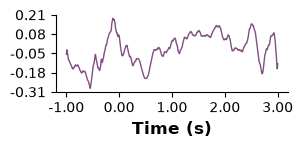

In [23]:
## Figure 5B, all
import matplotlib.pyplot as plt
import numpy as np
import scipy.io as sio
import pandas as pd
import scipy.stats as stats
from matplotlib.ticker import FuncFormatter
from statsmodels.stats.multitest import multipletests

# Load the pre-combined global ISTP.
istp_data = sio.loadmat(DATA_DIR / 'istp_global.mat')
istp_key = next(
    key for key in ('istp_global', 'istpglobal') if key in istp_data
 )
istp = istp_data[istp_key]

df = pd.read_excel(DATA_DIR / 'hddmstim_vatz_all_flip.xlsx')
rt_data = df['z_mvatz'].values #a: a_mvatz; v: v_mvatz; t: t_mvatz; z: z_mvatz

# Remove subject 71 from ISTP; the Excel data already contains 110 matched observations.
istp = np.delete(istp, 70, axis=0)
rt = rt_data[:istp.shape[0]]
if rt.shape[0] != istp.shape[0]:
    raise ValueError(f'RT and ISTP lengths differ: {rt.shape[0]} vs {istp.shape[0]}')

r = np.zeros(istp.shape[1])
p = np.ones(istp.shape[1])
for timepoint in range(istp.shape[1]):
    r[timepoint], p[timepoint] = stats.pearsonr(
        rt, istp[:, timepoint], alternative='two-sided'
    )

p_corrected = multipletests(p, method='fdr_bh')[1]
time = np.linspace(-1, 3, len(r))

fig, ax = plt.subplots(figsize=(3, 1))
ax.plot(time, r, color='#805080', linewidth=1)

significant_time = time[p_corrected <= 0.05]
if significant_time.size > 0:
    print(f'Significant time period: {significant_time[0]:.2f}-{significant_time[-1]:.2f} s')
    ax.hlines(
        y=0.48,
        xmin=significant_time[0],
        xmax=significant_time[-1],
        color='#805080',
        linewidth=2,
    )

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_xlabel('Time (s)', fontsize=12, fontname='Times New Roman', weight='bold')
ax.set_yticks(np.linspace(ax.get_ylim()[0], ax.get_ylim()[1], 5))

formatter = FuncFormatter(lambda value, position: f'{value:.2f}')
ax.xaxis.set_major_formatter(formatter)
ax.yaxis.set_major_formatter(formatter)
plt.show()

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


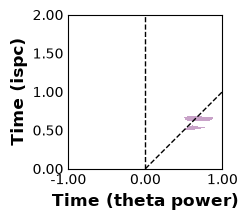

In [24]:
## Figure 5C, all
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.ticker import FuncFormatter

z_all = np.load(DATA_DIR / 'mediation_chan_v_filtered_z_all_flip.npy')
z = z_all[0, :, :]  # 0:frontal; 3:posterior; 6:frontal-posterior

colors = ['w', '#C8A2C8']  # light purple
cmap_custom = ListedColormap(colors)

fig, ax = plt.subplots(figsize=(2, 2))
im = ax.imshow(z[251:750, 0:100], aspect=1, interpolation='nearest',
               cmap=cmap_custom, origin='lower', extent=[-1, 1, 0, 2],
               vmin=0, vmax=1)

ax.vlines(x=0, ymin=0, ymax=2, color='black', linestyle='--', linewidth=1, zorder=5)
ax.plot([0, 1], [0, 1], color='black', linestyle='--', linewidth=1, zorder=5)

ax.set_xlabel('Time (theta power)', fontsize=12, fontname='Times New Roman', weight='bold')
ax.set_ylabel('Time (ispc)', fontsize=12, fontname='Times New Roman', weight='bold')
ax.set_yticks(np.linspace(ax.get_ylim()[0], ax.get_ylim()[1], 5))

formatter = FuncFormatter(lambda x, pos: '{:.2f}'.format(x))
ax.xaxis.set_major_formatter(formatter)
ax.yaxis.set_major_formatter(formatter)
plt.tick_params(axis='x', length=0)
plt.tick_params(axis='y', length=0)
plt.show()